In [1]:
import glob
from aind_ophys_utils.signal_utils import noise_std
from scipy.ndimage import median_filter
from scipy.signal import welch
from scipy.stats import norm
from statsmodels.robust.scale import mad
from dff import *

In [2]:
%matplotlib inline

In [3]:
def get_valid_corrected_f(path):
    dr = path.split("/")[-1]
    data = []
    with h5py.File(f"{path}/{dr}_data.h5") as f:
        for k in f['planes'].keys():
            data.append(f[f'planes/{k}/corrected_f'][f[f'planes/{k}/valid_roi_inds'][:]])
    return data

In [4]:
dirs = glob.glob("/data/test-dataset-for-dff_multiplane-ophys_02/*/*")
dirs

['/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/804670',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/775682',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/782149',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753562',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/729088',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/758265',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753561',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/724567',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/755212',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/759075',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/726433',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/747443',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/757436',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/69

In [5]:
traces = get_valid_corrected_f(dirs[0])

# Look at trace 29 and Gaussian noise in more detail 

In [6]:
trace = traces[0][29]
np.random.seed(0)
noise = np.random.randn(len(trace))

### mad estimate 

Noise estimates: trace 64.63 (true: unknown)   Noise 0.7571 (true: 1)


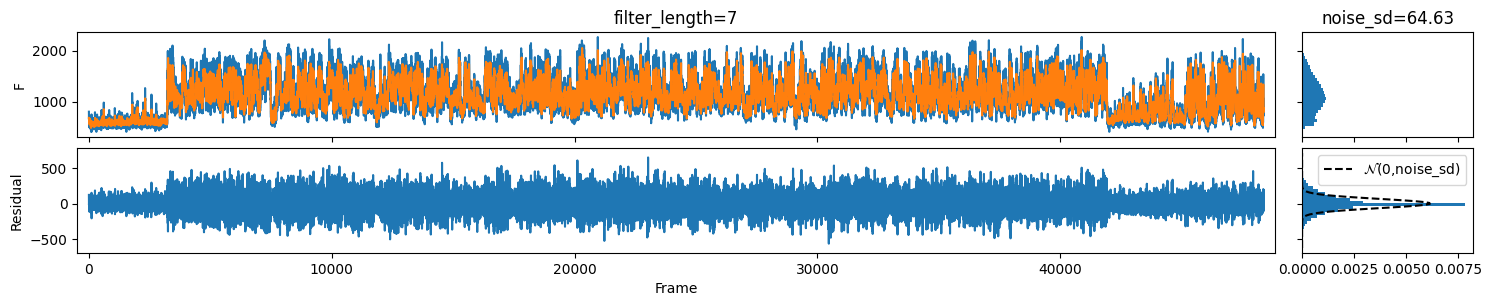

Noise estimates: trace 110.04 (true: unknown)   Noise 0.8902 (true: 1)


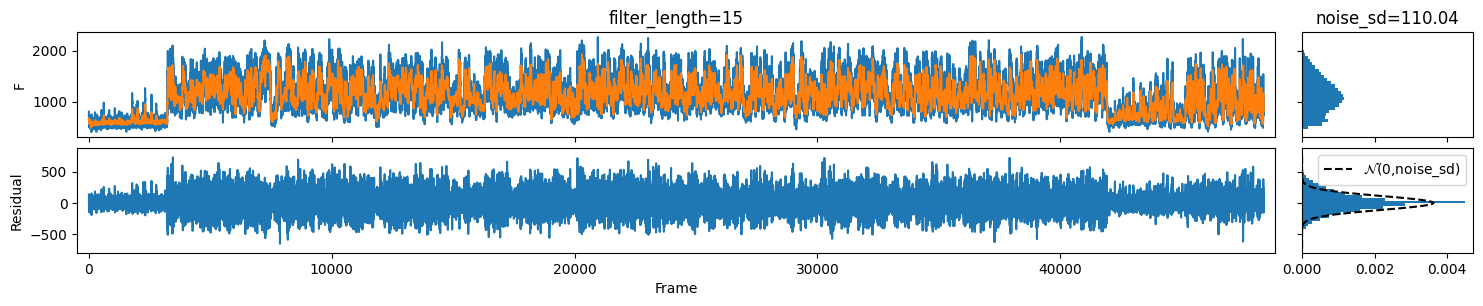

Noise estimates: trace 129.33 (true: unknown)   Noise 0.9311 (true: 1)


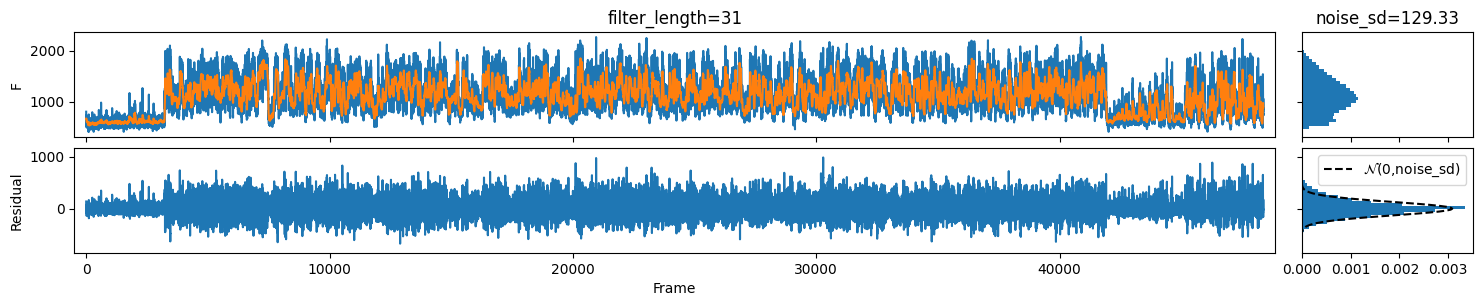

Noise estimates: trace 155.08 (true: unknown)   Noise 0.9519 (true: 1)


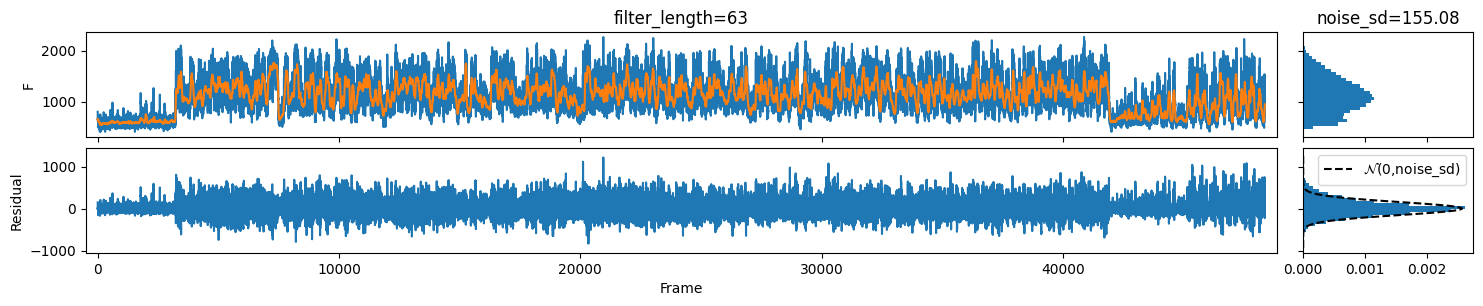

Noise estimates: trace 184.66 (true: unknown)   Noise 0.9641 (true: 1)


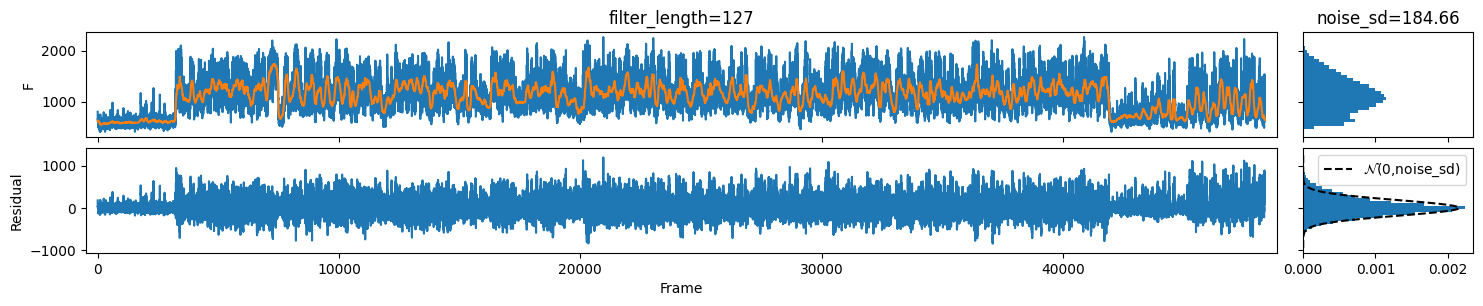

In [7]:
for filter_length in (7, 15, 31, 63, 127):
    noise_sd = [noise_std(t, method="mad", filter_length=filter_length, device="cpu") for t in (trace, noise)]
    print(f"Noise estimates: trace {noise_sd[0]:.2f} (true: unknown)   Noise {noise_sd[1]:.4f} (true: 1)")
    fig, ax = plt.subplots(2, 2, figsize=(15, 3), sharex="col", sharey="row", width_ratios=(7, 1))
    ax[0,0].plot(trace)
    filtered = median_filter(trace, filter_length)
    ax[0,0].plot(filtered)
    ax[0,0].set_title(f"filter_length={filter_length}")
    residual = trace - filtered
    ax[1,0].plot(residual)
    ax[1,0].set_xlabel("Frame")
    ax[1,0].set_ylabel("Residual")
    ax[0,0].set_ylabel("F")
    ax[1,0].set_xlim(-.01*len(trace), 1.01*len(trace))
    ax[0,1].hist(trace, 30, orientation='horizontal', density=True)
    ax[1,1].hist(residual, 30, orientation='horizontal', density=True)
    ax[0,1].set_title(f"noise_sd={noise_sd[0]:.2f}")
    y = np.linspace(*plt.ylim(), 100)
    p = norm.pdf(y, 0, noise_sd[0])
    plt.plot(p, y, 'k', ls="--", label='$\cal{N}$(0,noise_sd)')
    plt.legend()
    plt.tight_layout(pad=0.5)
    plt.show()

### PSD based estimate: using average power in high frequencies

In [8]:
for method in ("welch", "fft"):
    print(method)
    noise_sd = [noise_std(t, method=method, device="cpu") for t in (trace, noise)]
    print(f"Noise estimates: trace {noise_sd[0]:.2f} (true: unknown)   Noise {noise_sd[1]:.4f} (true: 1)")

welch
Noise estimates: trace 76.57 (true: unknown)   Noise 1.0067 (true: 1)
fft
Noise estimates: trace 74.36 (true: unknown)   Noise 1.0082 (true: 1)


89.4709 82.03072
85.419014 82.774185


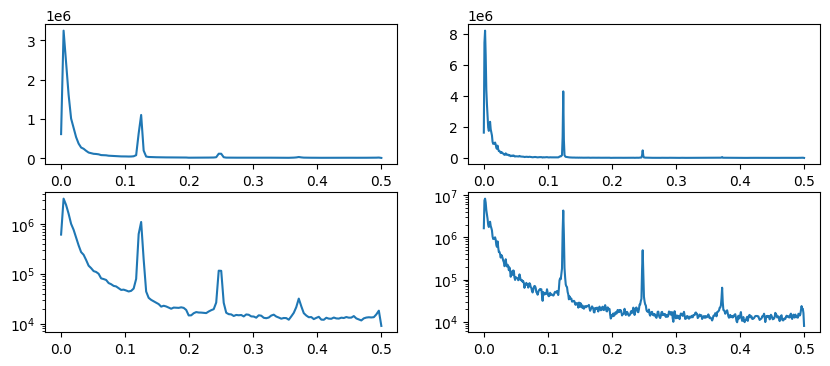

In [9]:
fig, ax = plt.subplots(2,2, figsize=(10,4))
for i, nperseg in enumerate((256, 1024)):
    ff, psd = welch(trace, nperseg=nperseg)
    ax[0,i].plot(ff, psd)
    ax[1,i].semilogy(ff, psd)
    noise_range = (0.25, 0.5)
    psd2 = psd[(ff >= noise_range[0]) & (ff < noise_range[1])] / 2
    print(np.sqrt(np.mean(psd2)), np.sqrt(np.median(psd2)))

In [10]:
def noise_std_psd_corrected_diff(
    x,
    fs=1.0,
    fmin=0.25,
    fmax=0.5,
    nperseg=1024,
):
    """
    PSD-corrected diff-based noise estimator.

    Parameters
    ----------
    x : array
        Input trace
    fs : float
        Sampling frequency
    fmin, fmax : float
        Fraction of Nyquist to use (e.g. 0.25–0.5)
    nperseg : int
        Welch segment length
    """
    dx = np.diff(x)

    f, psd = welch(dx, fs=fs, nperseg=nperseg)

    band = (f >= fmin * fs) & (f <= fmax * fs)

    # Transfer function of first difference
    omega = 2 * np.pi * f[band] / fs
    H2 = 4 * np.sin(omega / 2) ** 2

    sigma2 = np.mean(psd[band] / H2 / 2)
    return np.sqrt(sigma2)

<ipython-input-11-801d5a12a41c>:15: RuntimeWarning: divide by zero encountered in divide
  plt.semilogy(ff,psd / H2)


np.float64(85.34282648030943)

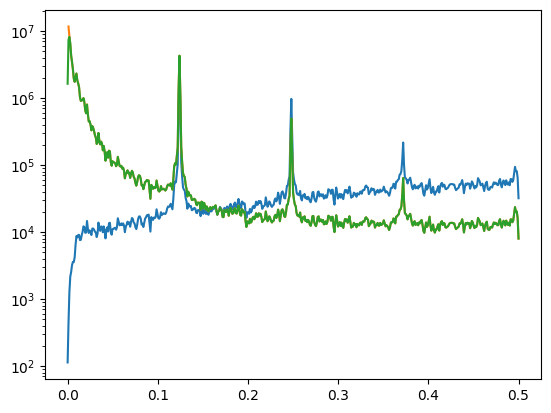

In [11]:
fmin=0.25
fmax=0.5

dx = np.diff(trace)

f, psd = welch(dx, fs=1, nperseg=1024)

band = (f >= fmin) & (f <= fmax)

# Transfer function of first difference
omega = 2 * np.pi * f#[band]
H2 = 4 * np.sin(omega / 2) ** 2

plt.semilogy(ff,psd)
plt.semilogy(ff,psd / H2)

ff, psd = welch(trace, nperseg=nperseg)
plt.semilogy(ff, psd)

noise_std_psd_corrected_diff(trace)

### diff based estimate

In [12]:
noise_sd = [np.std(np.diff(t)) / np.sqrt(2) for t in (trace, noise)]
print(f"std Noise estimates: trace {noise_sd[0]:6.2f} (true: unknown)   Noise {noise_sd[1]:.4f} (true: 1)")
noise_sd = [mad(np.diff(t)) / np.sqrt(2) for t in (trace, noise)]
print(f"mad Noise estimates: trace {noise_sd[0]:6.2f} (true: unknown)   Noise {noise_sd[1]:.4f} (true: 1)")

std Noise estimates: trace 105.31 (true: unknown)   Noise 0.9926 (true: 1)
mad Noise estimates: trace  90.87 (true: unknown)   Noise 0.9962 (true: 1)


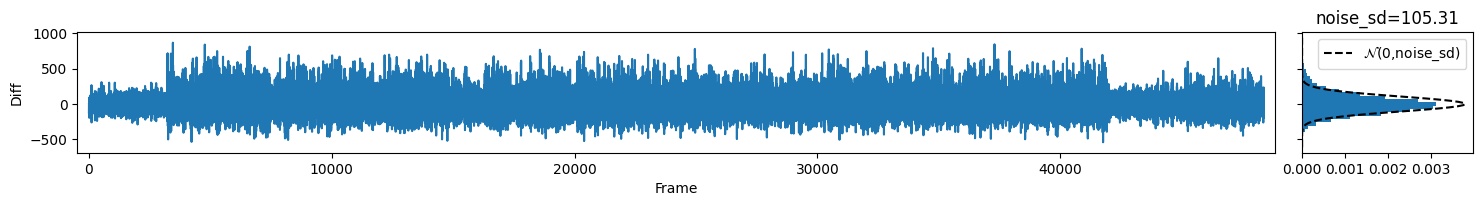

In [13]:
noise_sd = np.std(np.diff(trace)) / np.sqrt(2)
fig, ax = plt.subplots(1, 2, figsize=(15, 2), sharex="col", sharey="row", width_ratios=(7, 1))
ax[0].plot(np.diff(trace))
ax[0].set_xlabel("Frame")
ax[0].set_ylabel("Diff")
ax[0].set_xlim(-.01*len(trace), 1.01*len(trace))
ax[1].hist(np.diff(trace), 30, orientation='horizontal', density=True)
ax[1].set_title(f"noise_sd={noise_sd:.2f}")
y = np.linspace(*plt.ylim(), 100)
p = norm.pdf(y, 0, noise_sd)
ax[1].plot(p, y, 'k', ls="--", label='$\cal{N}$(0,noise_sd)')
ax[1].legend()
plt.tight_layout(pad=0.5)
plt.show()

## Downscale by 10x 

In [14]:
trace_ds = np.nanmean(trace[:len(trace)//10*10].reshape(-1, 10), 1)
noise_ds = np.nanmean(noise[:len(noise)//10*10].reshape(-1, 10), 1)

### mad estimate 

Noise estimates: trace 55.32 (true: unknown)   Noise 0.2355 (true: 1/sqrt(10))


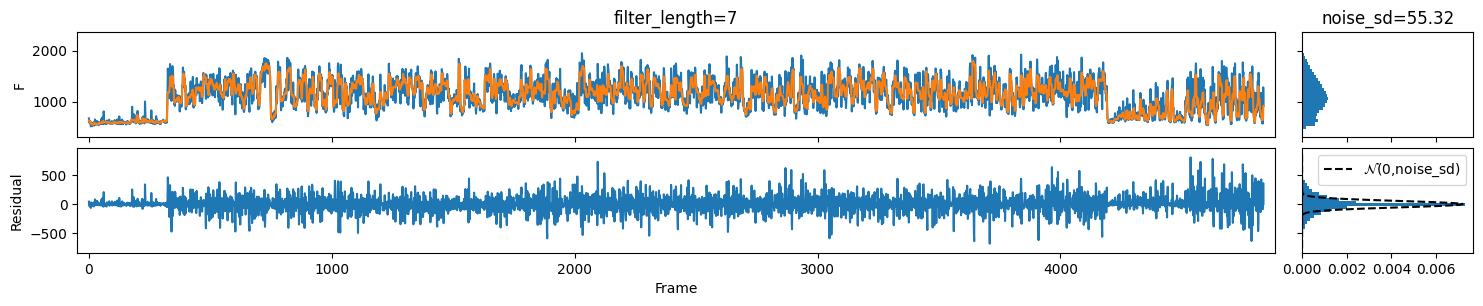

Noise estimates: trace 126.73 (true: unknown)   Noise 0.2668 (true: 1/sqrt(10))


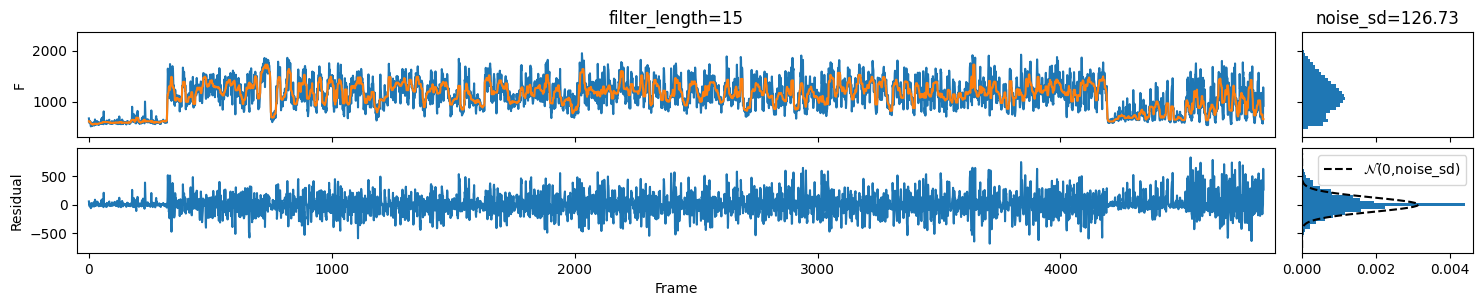

Noise estimates: trace 176.78 (true: unknown)   Noise 0.2851 (true: 1/sqrt(10))


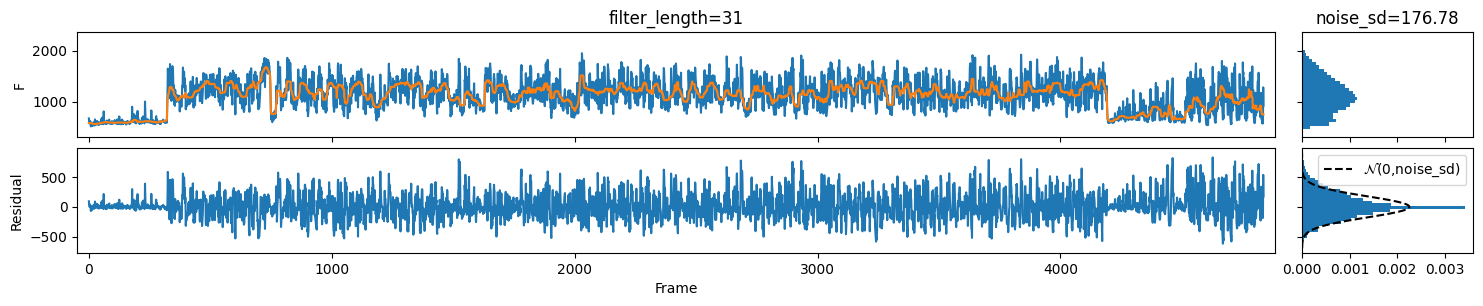

Noise estimates: trace 203.79 (true: unknown)   Noise 0.2986 (true: 1/sqrt(10))


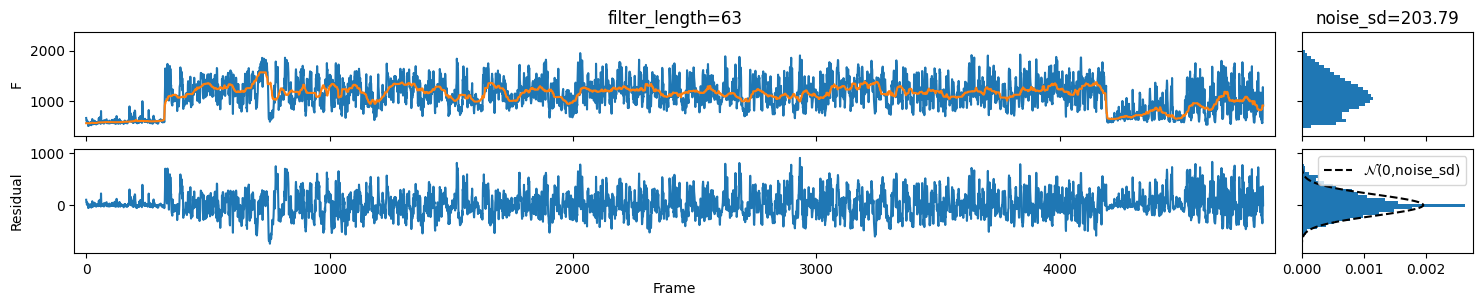

Noise estimates: trace 218.78 (true: unknown)   Noise 0.3020 (true: 1/sqrt(10))


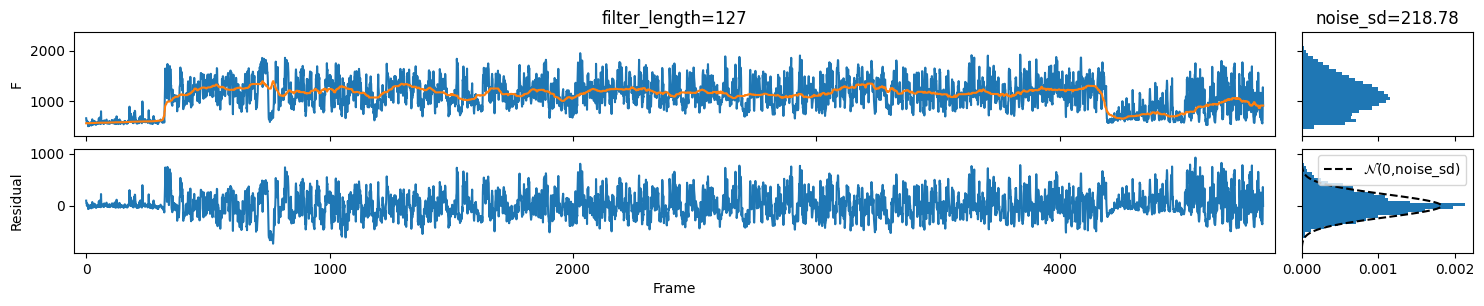

In [15]:
for filter_length in (7, 15, 31, 63, 127):
    noise_sd = [noise_std(t, method="mad", filter_length=filter_length, device="cpu") for t in (trace_ds, noise_ds)]
    print(f"Noise estimates: trace {noise_sd[0]:.2f} (true: unknown)   Noise {noise_sd[1]:.4f} (true: 1/sqrt(10))")
    fig, ax = plt.subplots(2, 2, figsize=(15, 3), sharex="col", sharey="row", width_ratios=(7, 1))
    ax[0,0].plot(trace_ds)
    filtered = median_filter(trace_ds, filter_length)
    ax[0,0].plot(filtered)
    ax[0,0].set_title(f"filter_length={filter_length}")
    residual = trace_ds - filtered
    ax[1,0].plot(residual)
    ax[1,0].set_xlabel("Frame")
    ax[1,0].set_ylabel("Residual")
    ax[0,0].set_ylabel("F")
    ax[1,0].set_xlim(-.01*len(trace_ds), 1.01*len(trace_ds))
    ax[0,1].hist(trace, 30, orientation='horizontal', density=True)
    ax[1,1].hist(residual, 30, orientation='horizontal', density=True)
    ax[0,1].set_title(f"noise_sd={noise_sd[0]:.2f}")
    y = np.linspace(*plt.ylim(), 100)
    p = norm.pdf(y, 0, noise_sd[0])
    plt.plot(p, y, 'k', ls="--", label='$\cal{N}$(0,noise_sd)')
    plt.legend()
    plt.tight_layout(pad=0.5)
    plt.show()

### PSD based estimate: using average power in high frequencies

In [16]:
for method in ("welch", "fft"):
    print(method)
    noise_sd = [noise_std(t, method=method, device="cpu") for t in (trace_ds, noise_ds)]
    print(f"Noise estimates: trace {noise_sd[0]:.2f} (true: unknown)   Noise {noise_sd[1]:.4f} (true: 1/sqrt(10))")

welch
Noise estimates: trace 93.26 (true: unknown)   Noise 0.3007 (true: 1/sqrt(10))
fft
Noise estimates: trace 94.07 (true: unknown)   Noise 0.3041 (true: 1/sqrt(10))


### diff based estimate

In [17]:
noise_sd = [np.std(np.diff(t)) / np.sqrt(2) for t in (trace_ds, noise_ds)]
print(f"std Noise estimates: trace {noise_sd[0]:6.2f} (true: unknown)   Noise {noise_sd[1]:.4f} (true: 1/sqrt(10))")
noise_sd = [mad(np.diff(t)) / np.sqrt(2) for t in (trace_ds, noise_ds)]
print(f"mad Noise estimates: trace {noise_sd[0]:6.2f} (true: unknown)   Noise {noise_sd[1]:.4f} (true: 1/sqrt(10))")

std Noise estimates: trace 120.97 (true: unknown)   Noise 0.3084 (true: 1/sqrt(10))
mad Noise estimates: trace  95.85 (true: unknown)   Noise 0.3076 (true: 1/sqrt(10))
